In [61]:
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import torch
import matplotlib.pyplot as plt
import pickle as pickle
import pyrovelocity
from pyrovelocity.api import train_model

In [127]:
def compute_mean_vector_field(
    pos,
    adata,
    basis="umap",
    n_jobs=1,
    spliced="spliced_pyro",
    raw=False,
):

    adata.var["velocity_genes"] = True

    if spliced == "spliced_pyro":
        if raw:
            ut = pos["ut"]
            st = pos["st"]
            ut = ut / ut.sum(axis=-1, keepdims=True)
            st = st / st.sum(axis=-1, keepdims=True)
        else:
            ut = pos["ut"]
            st = pos["st"]
        adata.layers["spliced_pyro"] = st.mean(0).squeeze()
        # if ('u_scale' in pos) and ('s_scale' in pos): # TODO: two scale for Normal distribution
        if "u_scale" in pos:  # only one scale for Poisson distribution
            adata.layers["velocity_pyro"] = (
                ut * pos["beta"] / pos["u_scale"] - st * pos["gamma"]
            ).mean(0)
        else:
            if "beta_k" in pos:
                adata.layers["velocity_pyro"] = (
                    (ut * pos["beta_k"] - pos["st"] * pos["gamma_k"]).mean(0).squeeze()
                )
            else:
                adata.layers["velocity_pyro"] = (
                    ut * pos["beta"] - pos["st"] * pos["gamma"]
                ).mean(0)
        try:
            scv.tl.velocity_graph(
                adata, vkey="velocity_pyro", xkey="spliced_pyro", n_jobs=n_jobs
            )
        except Exception as e:
            print(f"--> WARNING: Could not compute velocity graph. Error: {e}")
    elif spliced in ["Ms"]:
        ut = adata.layers["Mu"]
        st = adata.layers["Ms"]
        if ("u_scale" in pos) and ("s_scale" in pos):
            adata.layers["velocity_pyro"] = (
                ut * pos["beta"] / (pos["u_scale"] / pos["s_scale"]) - st * pos["gamma"]
            ).mean(0)
        else:
            adata.layers["velocity_pyro"] = (
                ut * pos["beta"] - pos["st"] * pos["gamma"]
            ).mean(0)
        scv.tl.velocity_graph(adata, vkey="velocity_pyro", xkey="Ms", n_jobs=n_jobs)
    elif spliced in ["spliced"]:
        ut = adata.layers["unspliced"]
        st = adata.layers["spliced"]
        if ("u_scale" in pos) and ("s_scale" in pos):
            adata.layers["velocity_pyro"] = (
                ut * pos["beta"] / (pos["u_scale"] / pos["s_scale"]) - st * pos["gamma"]
            ).mean(0)
        else:
            adata.layers["velocity_pyro"] = (
                ut * pos["beta"] - pos["st"] * pos["gamma"]
            ).mean(0)
        scv.tl.velocity_graph(
            adata, vkey="velocity_pyro", xkey="spliced", n_jobs=n_jobs
        )
    try:
        scv.tl.velocity_embedding(adata, vkey="velocity_pyro", basis=basis)
    except Exception as e:
            print(f"--> WARNING: Could not compute velocity graph. Error: {e}")
    

## Gastrulation erythroid

Filtered out 47456 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 3000 highly variable genes.
Logarithmized X.
computing neighbors
    finished (0:00:02) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:04) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
-----------
auto
auto
train_faster
TraceEnum
torch.Size([9815])
torch.Size([9815, 3000])
torch.Size([9815])
step    1 loss = 11.2385 patience = 45
step  100 loss = 8.2777 patience = 45
step  200 loss = 7.2358 patience = 45
step  300 loss = 6.61584 patience = 45
step  400 loss = 6.1306 patience = 40
step  500 loss = 5.7567 patience = 40
step  600 loss = 5.45989 patience = 43
step  699 loss = 5.22601 patience = 0
alpha before 144
gamma before 144
beta before 144
t0 before 144
u_scale before 144
dt_switching before 144
u_inf before 144
s_inf before 144
swit

  0%|          | 0/9815 [00:00<?, ?cells/s]

    finished (0:04:17) --> added 
    'velocity_pyro_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:03) --> added
    'velocity_pyro_umap', embedded velocity vectors (adata.obsm)
computing velocities
    finished (0:00:03) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 48/48 cores)


  0%|          | 0/9815 [00:00<?, ?cells/s]

    finished (0:00:44) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:03) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


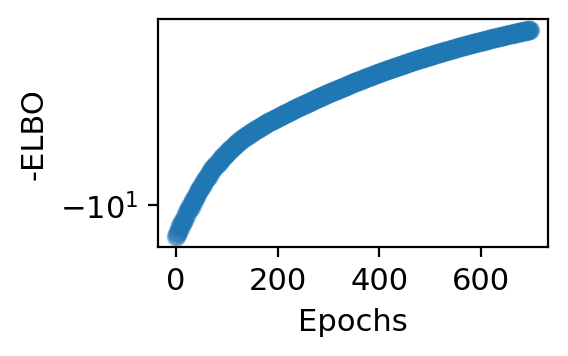

In [177]:
adata = sc.read_h5ad('../Data/gastrulation_erythroid.h5ad')

adata.layers['raw_spliced'] = adata.layers['spliced'].copy()
adata.layers['raw_unspliced'] = adata.layers['unspliced'].copy()

scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=3000)
scv.pp.moments(adata, n_neighbors=30, n_pcs=30)

adata.obs['u_lib_size_raw'] = adata.layers['raw_unspliced'].sum(-1)
adata.obs['s_lib_size_raw'] = adata.layers['raw_spliced'].sum(-1)

adata_model_pos = train_model(adata,
                              max_epochs=1000,
                              log_every=100,
                              patient_init=45,
                              batch_size=-1, 
                              use_gpu=False, 
                              cell_state='state_info',
                              include_prior=True,
                              offset=False,
                              library_size=True,
                              patient_improve=1e-3,
                              model_type='auto',
                              guide_type='auto',
                              train_size=1.0,   
                              num_samples = 30,
                             )
compute_mean_vector_field(adata_model_pos[1], adata)

scv.tl.velocity_graph(adata, vkey='velocity', n_jobs=-1)
scv.tl.velocity_embedding(adata, basis='umap', vkey='velocity')
fix, ax = plt.subplots(1, 1, figsize = (8, 6))
scv.pl.velocity_embedding_stream(adata1, basis='umap', save = False, vkey='velocity', color='celltype', title='pyro-velocity', fontsize=20, show = False, ax = ax, legend_fontsize = 15)
plt.savefig('../Gastrulation_Erythroid_Results/pyro-velocity_UMAP_stream.png', dpi=80)
adata.write_h5ad('../Gastrulation_Erythroid_Results/pyro-velocity.h5ad')

## Dentate Gyrus neurogenesis

Filtered out 10340 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 3000 highly variable genes.
Logarithmized X.
computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
-----------
auto
auto
train_faster
TraceEnum
torch.Size([2930])
torch.Size([2930, 3000])
torch.Size([2930])
step    1 loss = 2.68197 patience = 45
step  100 loss = 2.14354 patience = 45
step  200 loss = 1.93436 patience = 45
step  300 loss = 1.77948 patience = 41
step  400 loss = 1.6592 patience = 42
step  500 loss = 1.56378 patience = 44
step  600 loss = 1.48688 patience = 45
step  700 loss = 1.42843 patience = 44
step  800 loss = 1.38119 patience = 45
step  900 loss = 1.3431 patience = 43
step 1000 loss = 1.31467 patience = 40
alpha before 144
gamma be

  0%|          | 0/2930 [00:00<?, ?cells/s]

    finished (0:01:03) --> added 
    'velocity_pyro_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:01) --> added
    'velocity_pyro_umap', embedded velocity vectors (adata.obsm)
computing velocities
    finished (0:00:01) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 48/48 cores)


  0%|          | 0/2930 [00:00<?, ?cells/s]

    finished (0:00:36) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:01) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


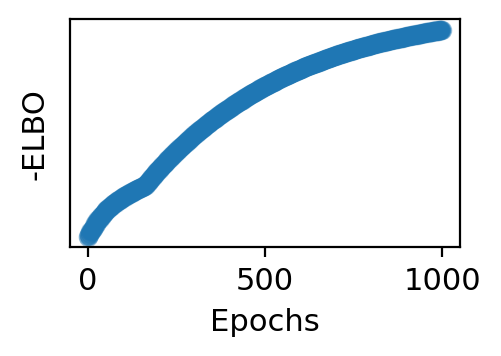

In [176]:
adata = sc.read_h5ad('../Data/DentateGyrus_10X43_1.h5ad')

adata.layers['raw_spliced'] = adata.layers['spliced'].copy()
adata.layers['raw_unspliced'] = adata.layers['unspliced'].copy()

scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=3000)
scv.pp.moments(adata, n_neighbors=30, n_pcs=30)

adata.obs['u_lib_size_raw'] = adata.layers['raw_unspliced'].sum(-1)
adata.obs['s_lib_size_raw'] = adata.layers['raw_spliced'].sum(-1)

adata_model_pos = train_model(adata,
                              max_epochs=1000,
                              log_every=100,
                              patient_init=45,
                              batch_size=-1, 
                              use_gpu=False, 
                              cell_state='state_info',
                              include_prior=True,
                              offset=False,
                              library_size=True,
                              patient_improve=1e-3,
                              model_type='auto',
                              guide_type='auto',
                              train_size=1.0,   
                              num_samples = 30,
                             )
compute_mean_vector_field(adata_model_pos[1], adata)

scv.tl.velocity_graph(adata, vkey='velocity', n_jobs=-1)
scv.tl.velocity_embedding(adata, basis='umap', vkey='velocity')
fix, ax = plt.subplots(1, 1, figsize = (8, 6))
scv.pl.velocity_embedding_stream(adata1, basis='umap', save = False, vkey='velocity', color='clusters', title='pyro-velocity', fontsize=20, show = False, ax = ax, legend_fontsize = 15)
plt.savefig('../Dentate_Gyrus_Results/pyro-velocity_UMAP_stream.png', dpi=80)
adata.write_h5ad('../Dentate_Gyrus_Results/pyro-velocity.h5ad')

## Simulated data

/tmp/ipykernel_29689/923417415.py:7: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  adata_umap = pickle.load(open(f'/home/ylz0045/Singlecell/RNAVelocity/our_perspective_TME_simulation/TME_simulation/sim1/PAGA/PAGA.pkl','rb'))


Normalized count data: X, spliced, unspliced.
Extracted 3 highly variable genes.
computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
or is corrupted (e.g. due to subsetting). Consider recomputing with `pp.neighbors`.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
-----------
auto
auto
train_faster
TraceEnum
torch.Size([4000])
torch.Size([4000, 3])
torch.Size([4000])
step    1 loss = 26.1408 patience = 45
step  100 loss = 18.4099 patience = 45
step  200 loss = 12.9673 patience = 44
step  300 loss = 9.42566 patience = 45
step  400 loss = 7.15721 patience = 44
step  500 loss = 5.78631 patience = 44
step  600 loss = 4.82036 patience = 45
step  700 loss = 4.30282 patience = 44
step  800 loss = 3.96193 patience = 44
step  900 loss = 3.78245 patience = 44
step 1000 loss = 3.65797 patience = 44
alpha before 144
gamma be

  0%|          | 0/4000 [00:00<?, ?cells/s]

    finished (0:00:29) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:01) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


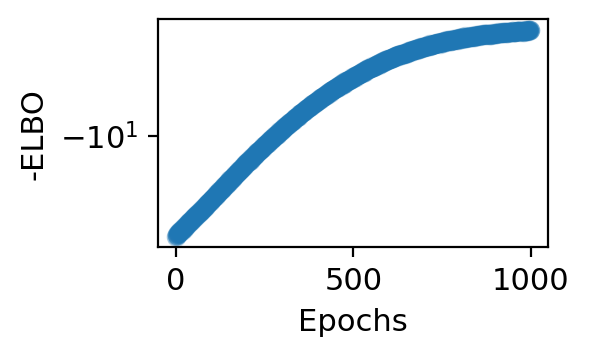

In [175]:
adata = sc.read_h5ad('../Data/simulated_T_cell_expint.h5ad')
adata.obsm['X_umap'] = pickle.load(open('../Data/UMAP.pkl','rb'))

adata.layers['raw_spliced'] = adata.layers['spliced'].copy()
adata.layers['raw_unspliced'] = adata.layers['unspliced'].copy()

scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=3)
scv.pp.moments(adata, n_neighbors=30, n_pcs=None)

adata.obs['u_lib_size_raw'] = adata.layers['raw_unspliced'].sum(-1)
adata.obs['s_lib_size_raw'] = adata.layers['raw_spliced'].sum(-1)

adata_model_pos = train_model(adata,
                              max_epochs=1000,
                              log_every=100,
                              patient_init=45,
                              batch_size=-1, 
                              use_gpu=False, 
                              cell_state='state_info',
                              include_prior=True,
                              offset=False,
                              library_size=True,
                              patient_improve=1e-3,
                              model_type='auto',
                              guide_type='auto', 
                              train_size=1.0,   
                              num_samples = 30, 
                             )
compute_mean_vector_field(adata_model_pos[1], adata)

scv.tl.velocity_graph(adata, vkey='velocity', n_jobs=-1)
scv.tl.velocity_embedding(adata, basis='umap', vkey='velocity')
fix, ax = plt.subplots(1, 1, figsize = (8, 6))
scv.pl.velocity_embedding_stream(adata, basis='umap', save = False, vkey='velocity', color='time', title='pyro-velocity', fontsize=20, show = False, ax = ax, legend_fontsize = 15)
plt.savefig('../Simulation_Results/pyro-velocity_UMAP_stream.png', dpi=80)
adata.write_h5ad('../Simulation_Results/pyro-velocity.h5ad')